# Inhomogeneous Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/ipp_from_scratch_and_numpyro.ipynb)

The **inhomogeneous Poisson process** (IPP) generalises the HPP by letting the intensity $\lambda(t)$ vary in time. The compensator $\Lambda(t) = \int_0^t \lambda(s)\, ds$ replaces the linear $\lambda t$, and the log-likelihood becomes

$$\log L\bigl(\{t_i\}_{i=1}^n\bigr) = \sum_{i=1}^n \log \lambda(t_i) \;-\; \Lambda(T).$$

This notebook shows both sides of the `xtremax` stack:

1. **From scratch** — call the pure primitives directly: Lewis–Shedler thinning to sample, `ipp_log_prob` to evaluate the likelihood, time-rescaling residuals for a goodness-of-fit check.
2. **With NumPyro** — wrap the IPP as a `numpyro.distributions.Distribution` and run NUTS over the log-rates of a piecewise-constant intensity.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes.distributions import (
    InhomogeneousPoissonProcess as IppDist,
)
from xtremax.point_processes.operators import PiecewiseConstantLogIntensity
from xtremax.point_processes.primitives import (
    ipp_log_prob,
    ipp_sample_thinning,
    ks_statistic_exp1,
    qq_exp1_quantiles,
    time_rescaling_residuals,
)


plt.rcParams["figure.figsize"] = (8.0, 3.5)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

Pick a piecewise-constant log-intensity. Three bins, three rates. `PiecewiseConstantLogIntensity` is an `eqx.Module` that stores `bin_edges` and `log_rates` as PyTree leaves; for our purposes here we just need two things from it: it's a callable `log_intensity_fn(t)` that returns $\log \lambda(t)$, and it has a closed-form `.integrate(a, b)` that returns $\int_a^b \lambda(s)\, ds$ exactly.

In [2]:
true_bin_edges = jnp.array([0.0, 5.0, 12.0, 20.0])
true_rates = jnp.array([1.0, 5.0, 2.0])
true_intensity = PiecewiseConstantLogIntensity(
    bin_edges=true_bin_edges, rates=true_rates
)

T = float(true_bin_edges[-1])
true_Lambda_T = true_intensity.integrate(0.0, T)
true_lambda_max = true_intensity.max_intensity()
print(f"Λ(T) (closed form)   = {float(true_Lambda_T):.3f}")
print(f"λ_max (closed form)  = {float(true_lambda_max):.3f}")

Λ(T) (closed form)   = 56.000
λ_max (closed form)  = 5.000


### Sampling via Lewis–Shedler thinning

The `ipp_sample_thinning` primitive oversamples from a homogeneous process at rate $\lambda_\max$ and accepts each candidate with probability $\lambda(t) / \lambda_\max$. It returns `(times, mask, n_candidates_uncapped)` on a static buffer so the routine stays `jit`-compatible.

Accepted 42 events out of 85 candidates


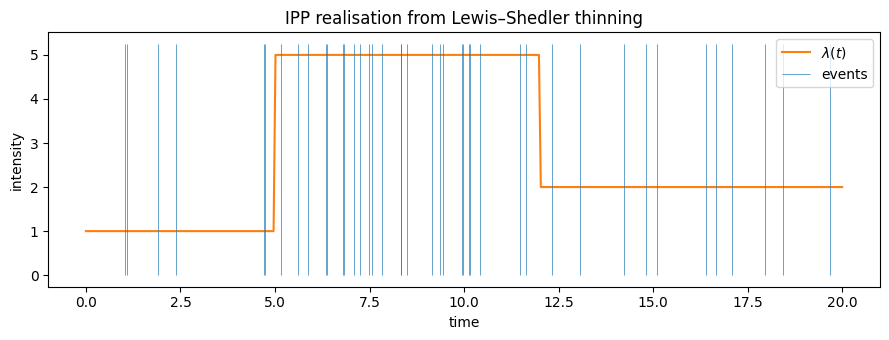

In [3]:
times, mask, n_cand = ipp_sample_thinning(
    key=random.PRNGKey(0),
    log_intensity_fn=true_intensity,
    T=T,
    lambda_max=true_lambda_max,
    max_candidates=256,
)
print(f"Accepted {int(mask.sum())} events out of {int(n_cand)} candidates")

fig, ax = plt.subplots(figsize=(9, 3.5))
grid = np.linspace(0, T, 400)
ax.plot(
    grid,
    np.asarray(jnp.exp(true_intensity(jnp.asarray(grid)))),
    color="C1",
    label=r"$\lambda(t)$",
)
ax.vlines(
    np.asarray(times[mask]),
    0,
    float(true_lambda_max) * 1.05,
    color="C0",
    linewidth=0.6,
    alpha=0.8,
    label="events",
)
ax.set_xlabel("time")
ax.set_ylabel("intensity")
ax.set_title("IPP realisation from Lewis–Shedler thinning")
ax.legend()
plt.tight_layout()
plt.show()

### Evaluating the log-likelihood

`ipp_log_prob(event_times, mask, log_intensity_fn, integrated_intensity)` returns $\sum_i \log \lambda(t_i) - \Lambda(T)$. We can compute $\Lambda(T)$ once via the closed-form `.integrate` method and reuse it.

In [4]:
Lambda_T = true_intensity.integrate(0.0, T)
log_L = ipp_log_prob(times, mask, true_intensity, Lambda_T)
print(f"log L at the true intensity: {float(log_L):.3f}")

log L at the true intensity: -8.139


### Goodness-of-fit via the time-rescaling theorem

Under the **time-rescaling theorem**, if $\Lambda$ is the correct compensator of the process, the rescaled inter-event times $\tau_i = \Lambda(t_i) - \Lambda(t_{i-1})$ are i.i.d. $\mathrm{Exp}(1)$. Plugging the compensator into `time_rescaling_residuals` and then through `ks_statistic_exp1` gives a one-line goodness-of-fit check that works for any point-process model with a well-defined compensator.

KS statistic (correct compensator) : 0.089
KS statistic (wrong λ≡1)          : 0.462


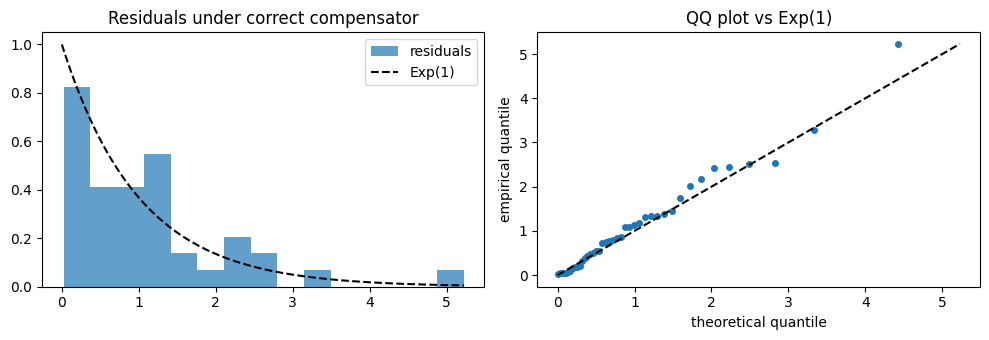

In [5]:
def Lambda_correct(t):
    # Vectorised over a batched ``t`` using the module's closed form.
    flat_t = jnp.atleast_1d(jnp.asarray(t))
    zeros = jnp.zeros_like(flat_t)
    return jax.vmap(true_intensity.integrate)(zeros, flat_t).reshape(jnp.shape(t))


residuals, res_mask = time_rescaling_residuals(times, mask, Lambda_correct)
ks = ks_statistic_exp1(residuals, res_mask)
theo, emp = qq_exp1_quantiles(residuals, res_mask)
print(f"KS statistic (correct compensator) : {float(ks):.3f}")


# Wrong compensator — pretend the process is HPP with λ=1.
def Lambda_wrong(t):
    return jnp.asarray(t)


res_w, _ = time_rescaling_residuals(times, mask, Lambda_wrong)
ks_w = ks_statistic_exp1(res_w, res_mask)
print(f"KS statistic (wrong λ≡1)          : {float(ks_w):.3f}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))

real_res = np.asarray(residuals[res_mask])
ax0.hist(real_res, bins=15, density=True, alpha=0.7, color="C0", label="residuals")
xx = np.linspace(0, real_res.max(), 200)
ax0.plot(xx, np.exp(-xx), "k--", label=r"Exp(1)")
ax0.legend()
ax0.set_title("Residuals under correct compensator")

theo_np = np.asarray(theo)
emp_np = np.asarray(emp)
good = ~np.isnan(theo_np)
ax1.plot(theo_np[good], emp_np[good], "o", color="C0", markersize=4)
lim = max(theo_np[good].max(), emp_np[good].max())
ax1.plot([0, lim], [0, lim], "k--")
ax1.set_xlabel("theoretical quantile")
ax1.set_ylabel("empirical quantile")
ax1.set_title("QQ plot vs Exp(1)")
plt.tight_layout()
plt.show()

## 2. With NumPyro — Bayesian inference over log-rates

To recover the bin rates from the event sequence we put a prior on the per-bin log-rates and run NUTS. The IPP likelihood is `IppDist(...).log_prob((times, mask))`, evaluated with a freshly-constructed intensity at each MCMC step.

The operator (and therefore the distribution wrapper) queries $\Lambda(T)$ from the **current** intensity module on every `log_prob` call, so the $-\Lambda(T)$ term tracks updated log-rates automatically — crucial for Bayesian inference and for any gradient-based downstream use.

In [6]:
def bayesian_model(times, mask, bin_edges):
    n_bins = bin_edges.shape[0] - 1
    log_rates = numpyro.sample(
        "log_rates",
        dist.Normal(jnp.zeros(n_bins), 2.0 * jnp.ones(n_bins)),
    )
    intensity_fn = PiecewiseConstantLogIntensity(
        bin_edges=bin_edges, log_rates=log_rates
    )
    ipp = IppDist(
        log_intensity_fn=intensity_fn,
        observation_window=bin_edges[-1],
        max_candidates=256,
    )
    numpyro.factor("lik", ipp.log_prob((times, mask)))


mcmc = MCMC(
    NUTS(bayesian_model),
    num_warmup=500,
    num_samples=1000,
    progress_bar=False,
)
mcmc.run(random.PRNGKey(0), times=times, mask=mask, bin_edges=true_bin_edges)
samples = mcmc.get_samples()
rate_samples = np.exp(np.asarray(samples["log_rates"]))

print("Posterior summary (rates):")
for b in range(true_rates.shape[0]):
    mean = rate_samples[:, b].mean()
    lo = np.quantile(rate_samples[:, b], 0.025)
    hi = np.quantile(rate_samples[:, b], 0.975)
    print(
        f"  bin {b}: mean {mean:.2f}, 95% CI [{lo:.2f}, {hi:.2f}], "
        f"true {float(true_rates[b]):.2f}"
    )

Posterior summary (rates):
  bin 0: mean 1.20, 95% CI [0.44, 2.28], true 1.00
  bin 1: mean 3.53, 95% CI [2.29, 5.06], true 5.00
  bin 2: mean 1.36, 95% CI [0.66, 2.32], true 2.00


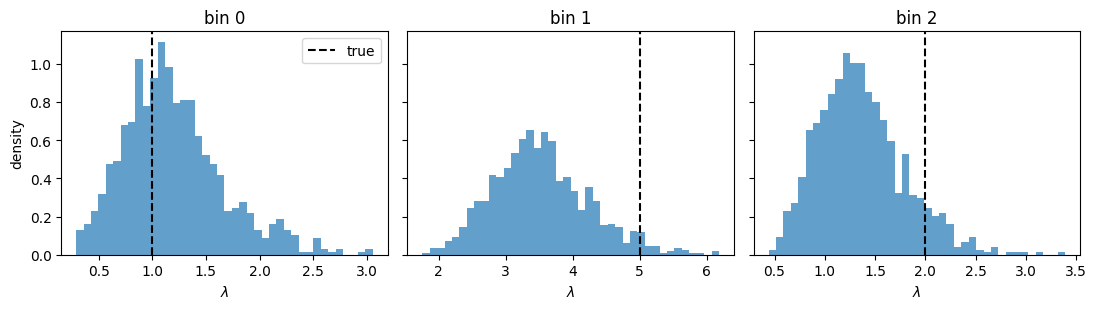

In [7]:
fig, axes = plt.subplots(1, true_rates.shape[0], figsize=(11, 3.2), sharey=True)
for b, ax in enumerate(axes):
    ax.hist(rate_samples[:, b], bins=40, density=True, alpha=0.7, color="C0")
    ax.axvline(float(true_rates[b]), color="k", linestyle="--", label="true")
    ax.set_title(f"bin {b}")
    ax.set_xlabel(r"$\lambda$")
    if b == 0:
        ax.set_ylabel("density")
        ax.legend()
plt.tight_layout()
plt.show()

### Posterior predictive check

Draw per-bin rate vectors from the posterior, simulate new event sequences, and compare the mean intensity profile with the truth. (We hold the bin edges fixed; the uncertainty is entirely on the rates.)

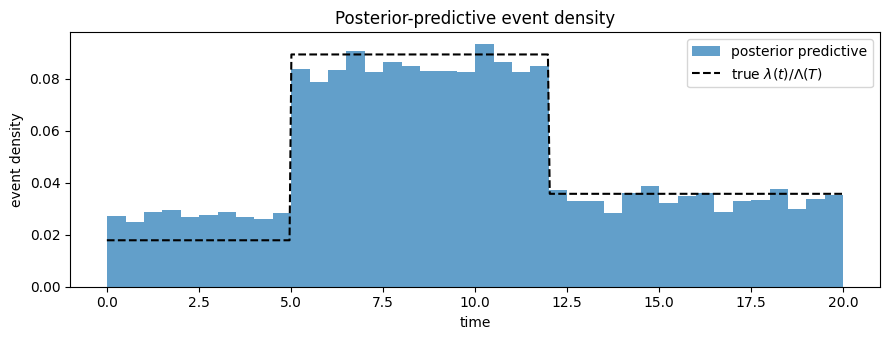

In [8]:
def simulate_once(key, log_rates):
    intensity = PiecewiseConstantLogIntensity(
        bin_edges=true_bin_edges, log_rates=log_rates
    )
    lam_max = intensity.max_intensity()
    ts, msk, _ = ipp_sample_thinning(key, intensity, T, lam_max, max_candidates=256)
    return ts, msk


keys_pp = random.split(random.PRNGKey(3), 200)
log_rates_pp = jnp.asarray(samples["log_rates"][:200])
ts_pp, msk_pp = jax.vmap(simulate_once)(keys_pp, log_rates_pp)

# Histogram events across posterior-predictive draws.
all_times = np.asarray(ts_pp)[np.asarray(msk_pp)]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(
    all_times,
    bins=40,
    density=True,
    alpha=0.7,
    color="C0",
    label="posterior predictive",
)
grid = np.linspace(0, T, 400)
ax.plot(
    grid,
    np.asarray(jnp.exp(true_intensity(jnp.asarray(grid)))) / float(true_Lambda_T),
    "k--",
    label=r"true $\lambda(t) / \Lambda(T)$",
)
ax.set_xlabel("time")
ax.set_ylabel("event density")
ax.set_title("Posterior-predictive event density")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

* **Primitives** are enough to sample, evaluate the likelihood, and run time-rescaling goodness-of-fit for any intensity $\lambda(t)$ — no operator or distribution required.
* **`PiecewiseConstantLogIntensity`** is the natural parameterisation for piecewise-constant rates: its `log_rates` leaf is both a plain `eqx.Module` parameter (jit/vmap/grad friendly) and a NumPyro-friendly field (samplable via `numpyro.sample`).
* The operator's `.log_prob` always computes $\Lambda(T)$ from the **live** intensity, so posteriors from NUTS (or any gradient-based optimiser) see the full likelihood — the $\sum \log \lambda(t_i)$ term *and* the $-\Lambda(T)$ term — rather than a stale cache.